# HOMEWORK 9

In this homework, you are going to use the dlib face detector and apply it to an image of your liking. You can follow the procedure shown in lesson 9. Please always comment your code so I can see what you're doing :-)

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.

In [1]:
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = [15, 10]

In [3]:
def plot_grid(images, bboxes = None, grid_size=(2, 2)):
    """
    Plot a grid of images with optional bounding boxes.

    This function displays a grid of images, with the option to overlay bounding boxes
    on each image. It is useful for visualizing the results of object detection algorithms.

    Parameters
    ----------
    images : list
        A list of images to display.
    bboxes : list | None, optional
        A list of bounding boxes for each image, by default None
    grid_size : tuple, optional
        The number of rows and columns in the grid, by default (2, 2)
    """
    ncols, nrows = grid_size

    fig, axes = plt.subplots(nrows, ncols)
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        img_to_plot = images[i].copy()

        if bboxes:
            for bbox in bboxes[i]:
                if hasattr(bbox, "rect"):
                    bbox = bbox.rect
                pt1 = (bbox.left(), bbox.top())
                pt2 = (bbox.right(), bbox.bottom())
                random_color = tuple(np.random.randint(0, 255, 3).astype(int).tolist())
                cv2.rectangle(img_to_plot, pt1, pt2, color=random_color, thickness=2)

        ax.imshow(img_to_plot)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### Step 1

Load an image (any image that contains faces).

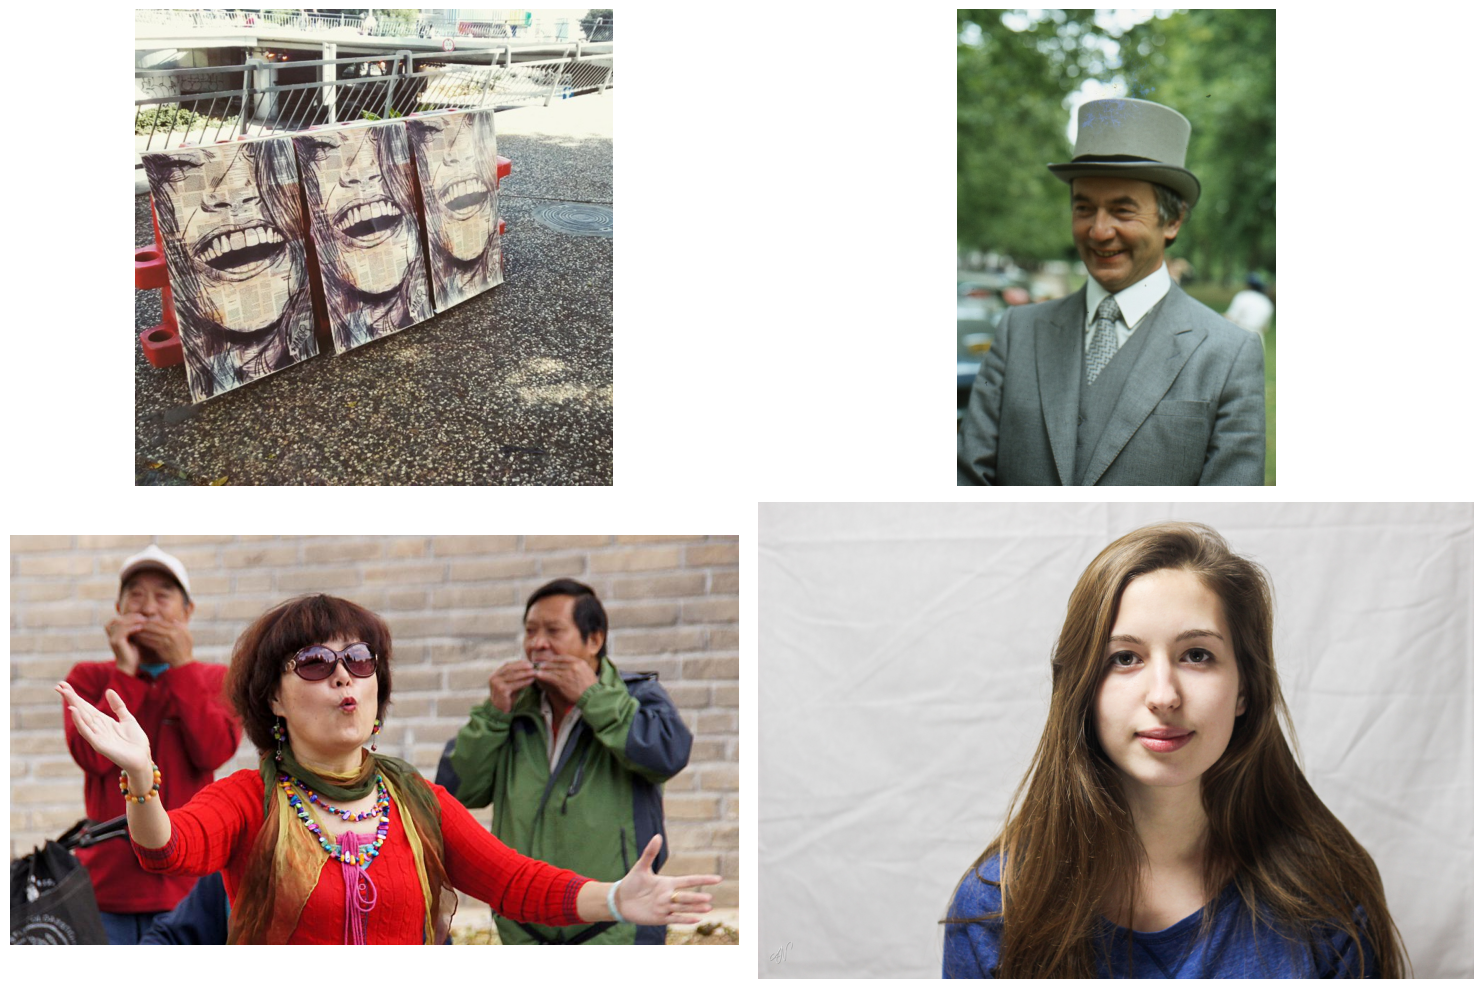

In [4]:
images = [cv2.cvtColor(cv2.imread(f"./data/{i}.jpg"), cv2.COLOR_BGR2RGB) for i in range(1, 5)]
plot_grid(images)

### Step 2

Load the dlib face predictor.

In [5]:
detector = dlib.get_frontal_face_detector()

### Step 3

Run the predictor on your image.

In [6]:
bboxes = [detector(image) for image in images]

### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

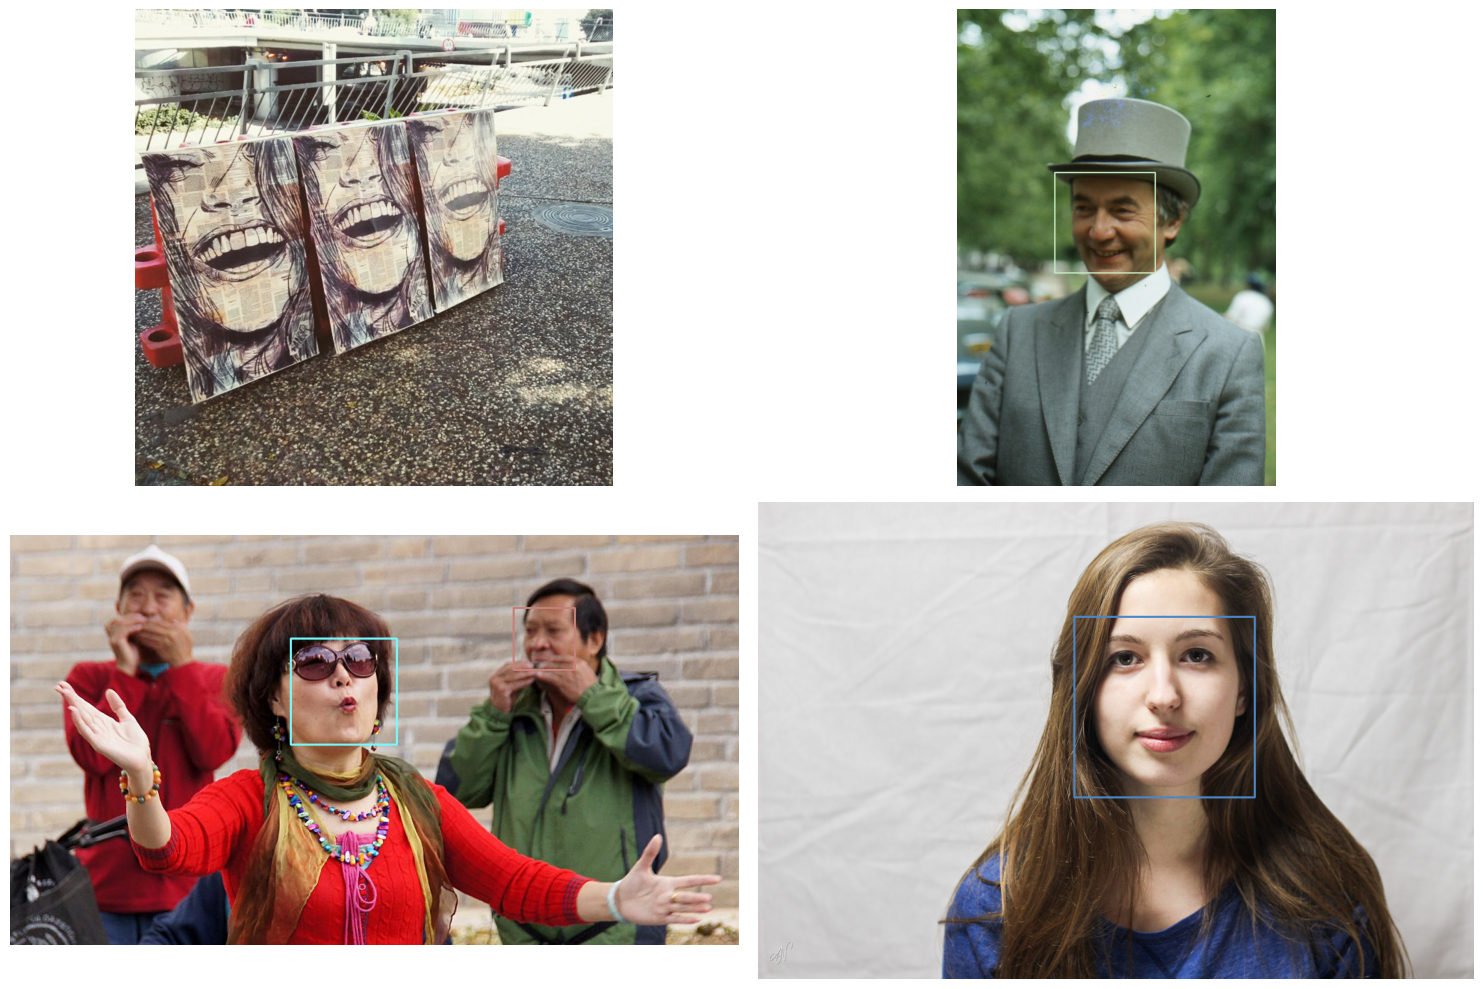

In [7]:
plot_grid(images, bboxes)

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

Detector worked unexpectedly good - it detected slightly rotated face, face in glasses and face of a person in the hat just like the front-facing face. Though it failed on a painings of faces as well as half-covered up face

### mmod_human_face_detector


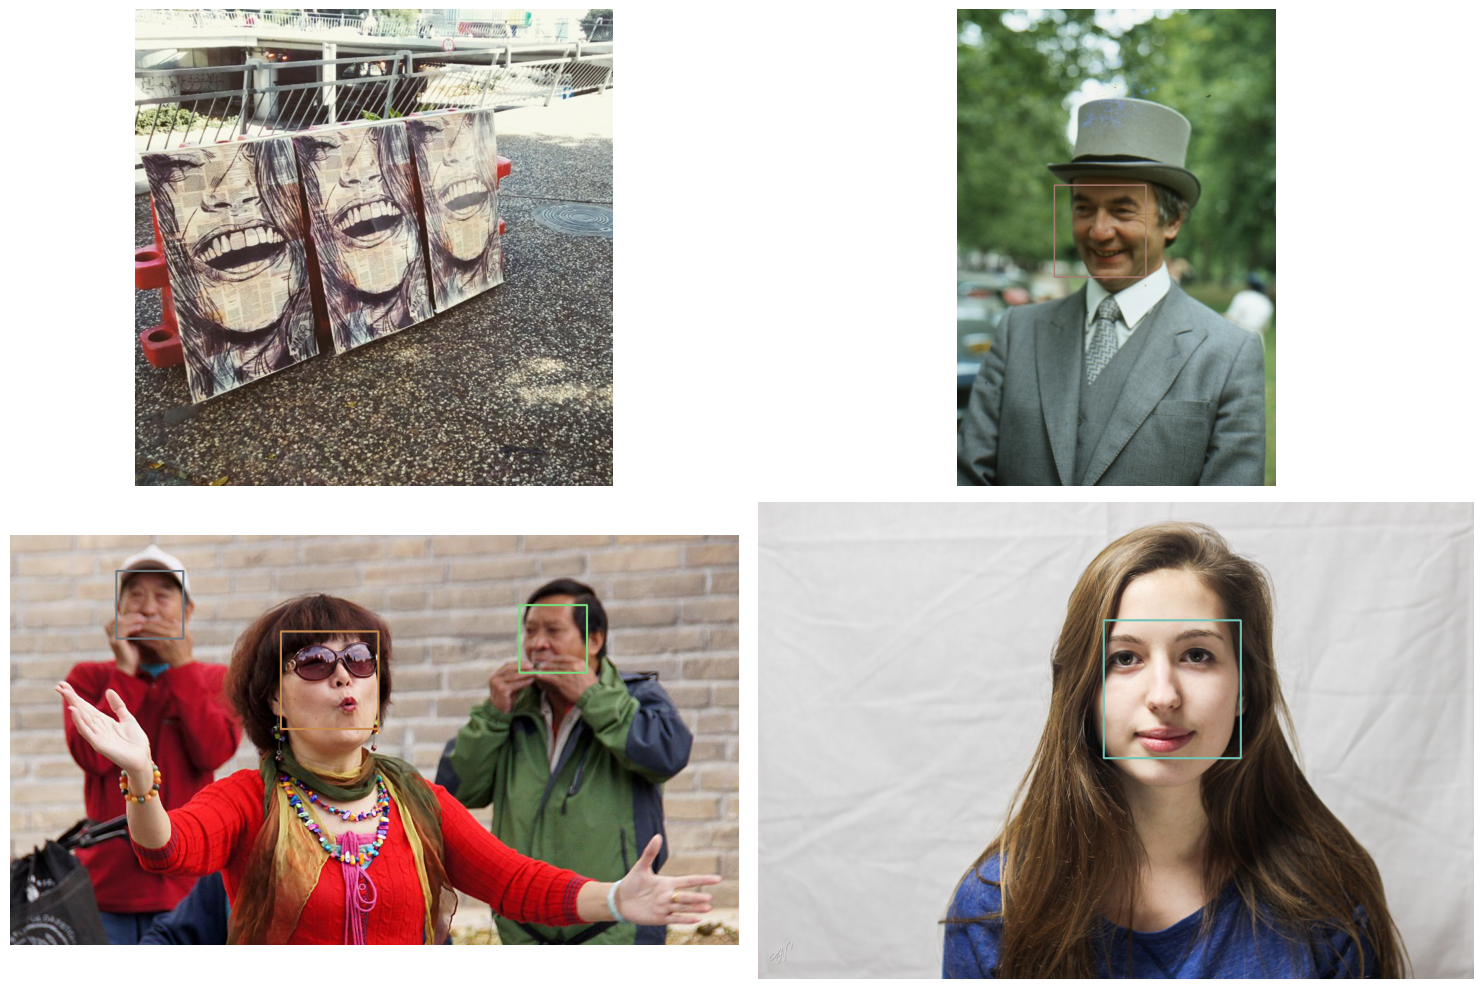

In [8]:
# model from https://github.com/davisking/dlib-models/raw/refs/heads/master/mmod_human_face_detector.dat.bz2
detector = dlib.cnn_face_detection_model_v1("mmod_human_face_detector.dat")
bboxes = [detector(image) for image in images]
plot_grid(images, bboxes)

This one is a bit better - it detected half-covered face, but still not the face on painting